# BK Sentinel — Notebook 04: Layer 3 Absorption State Analysis

**Project:** BK Sentinel — Three-Layer Dynamic Credit Risk Transition System  

---

This notebook covers Layer 3 of BK Sentinel:
1. Identify absorbing and transient states
2. Test state communicability
3. Build the canonical form — separate Q and R matrices
4. Compute the fundamental matrix N = (I − Q)⁻¹
5. Compute absorption probabilities B = N × R
6. Compute expected months to Default absorption
7. Visualise all results
8. Save outputs for the dashboard

---

**The core theory (Kemeny and Snell, 1960):**

An absorbing Markov chain has at least one state that, once entered, cannot be left.  
In BK's portfolio, **Default is that state** — with 99.72% monthly self-transition.  

The states that can eventually lead to Default but are not themselves absorbing are called **transient states**.  
In BK's portfolio: **Low, Medium, and High** are transient states.

The fundamental matrix N = (I − Q)⁻¹ answers:  
*How many months will an account starting in state i spend in state j before eventually being absorbed into Default?*

Multiplying N by R gives B = N × R, which answers:  
*What is the probability that an account currently in state i will eventually end up in Default?*

## 0. Import libraries

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from numpy.linalg import inv, matrix_power

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)

STATES = ['Low', 'Medium', 'High', 'Default']
TRANSIENT = ['Low', 'Medium', 'High']
ABSORBING = ['Default']
COLORS = {'Low': '#2ecc71', 'Medium': '#f39c12', 'High': '#e74c3c', 'Default': '#8e44ad'}

print('Libraries imported successfully.')

Libraries imported successfully.


## 1. Load the transition matrix

In [15]:
P_df = pd.read_csv('bk_transition_matrix.csv', index_col=0)
P_df = P_df.reindex(index=STATES, columns=STATES)
P = P_df.values

print('Transition matrix loaded:')
print(P_df.round(4))

Transition matrix loaded:
           Low  Medium   High  Default
From                                  
Low     0.9406  0.0537 0.0029   0.0029
Medium  0.1812  0.7088 0.1091   0.0009
High    0.0000  0.0954 0.6822   0.2224
Default 0.0008  0.0015 0.0005   0.9972


## 2. Identify absorbing and transient states

A state is absorbing if its self-transition probability is >= 0.95.
This means once you enter it, you essentially cannot leave.

All other states that can eventually lead to an absorbing state are called transient states.

In [16]:
print('=' * 55)
print('STEP 1: IDENTIFYING ABSORBING AND TRANSIENT STATES')
print('=' * 55)

THRESHOLD = 0.95
absorbing_states = []
transient_states = []

for i, state in enumerate(STATES):
    self_prob = P[i, i]
    if self_prob >= THRESHOLD:
        absorbing_states.append(state)
        status = f'ABSORBING (self-transition = {self_prob:.4f} >= {THRESHOLD})'
    else:
        transient_states.append(state)
        status = f'TRANSIENT (self-transition = {self_prob:.4f} < {THRESHOLD})'
    print(f'  {state:<10}: {status}')

print(f'\nAbsorbing states: {absorbing_states}')
print(f'Transient states: {transient_states}')
print(f'\nDefault qualifies as absorbing at {P[3,3]:.4f} monthly self-transition.')
print(f'This formally satisfies the Kemeny and Snell (1960) absorbing state criterion.')

STEP 1: IDENTIFYING ABSORBING AND TRANSIENT STATES
  Low       : TRANSIENT (self-transition = 0.9406 < 0.95)
  Medium    : TRANSIENT (self-transition = 0.7088 < 0.95)
  High      : TRANSIENT (self-transition = 0.6822 < 0.95)
  Default   : ABSORBING (self-transition = 0.9972 >= 0.95)

Absorbing states: ['Default']
Transient states: ['Low', 'Medium', 'High']

Default qualifies as absorbing at 0.9972 monthly self-transition.
This formally satisfies the Kemeny and Snell (1960) absorbing state criterion.


## 3. Test state communicability

Two states communicate if you can get from one to the other and back again.
Transient states should be able to reach the absorbing state (Default) eventually.
We verify this by checking if the probability of reaching Default from each transient state
becomes non-zero over many steps.

In [17]:
print('=' * 55)
print('STEP 2: STATE COMMUNICABILITY TEST')
print('=' * 55)

# Raise P to a large power — if any transient state can reach Default
# eventually, the Default column will be non-zero for that row
P_large = matrix_power(P, 100)

print('\nProbability of reaching Default from each state after 100 months:')
default_col = STATES.index('Default')
all_can_reach = True

for i, state in enumerate(STATES):
    prob = P_large[i, default_col]
    can_reach = prob > 0.001
    if state in transient_states and not can_reach:
        all_can_reach = False
    print(f'  {state:<10}: {prob:.4f} ({"can reach Default" if can_reach else "cannot reach Default"})')

print()
if all_can_reach:
    print('All transient states can eventually reach Default.')
    print('The chain is a valid absorbing Markov chain.')
else:
    print('WARNING: Some transient states cannot reach Default.')

STEP 2: STATE COMMUNICABILITY TEST

Probability of reaching Default from each state after 100 months:
  Low       : 0.7579 (can reach Default)
  Medium    : 0.7929 (can reach Default)
  High      : 0.8674 (can reach Default)
  Default   : 0.9011 (can reach Default)

All transient states can eventually reach Default.
The chain is a valid absorbing Markov chain.


## 4. Build the canonical form — Q and R matrices

The canonical form reorganises the transition matrix by separating:

**Q matrix** — transitions between transient states only (Low, Medium, High → Low, Medium, High)
This tells us how accounts move among the non-default states.

**R matrix** — transitions from transient states to absorbing states (Low, Medium, High → Default)
This tells us the monthly probability of each transient state falling into Default.

In [18]:
print('=' * 55)
print('STEP 3: CANONICAL FORM — Q AND R MATRICES')
print('=' * 55)

# Get indices
t_idx = [STATES.index(s) for s in transient_states]  # [0, 1, 2]
a_idx = [STATES.index(s) for s in absorbing_states]  # [3]

# Q matrix: transient rows, transient columns
Q = P[np.ix_(t_idx, t_idx)]
Q_df = pd.DataFrame(Q, index=transient_states, columns=transient_states)

# R matrix: transient rows, absorbing columns
R = P[np.ix_(t_idx, a_idx)]
R_df = pd.DataFrame(R, index=transient_states, columns=absorbing_states)

print('\nQ matrix (transient → transient transitions):')
print(Q_df.round(4))
print()
print('R matrix (transient → absorbing transitions):')
print(R_df.round(4))

print('\nVerification: Q row sums + R row sums should equal 1.0:')
for i, state in enumerate(transient_states):
    total = Q[i].sum() + R[i].sum()
    print(f'  {state}: {Q[i].sum():.4f} + {R[i].sum():.4f} = {total:.4f}')

STEP 3: CANONICAL FORM — Q AND R MATRICES

Q matrix (transient → transient transitions):
          Low  Medium   High
Low    0.9406  0.0537 0.0029
Medium 0.1812  0.7088 0.1091
High   0.0000  0.0954 0.6822

R matrix (transient → absorbing transitions):
        Default
Low      0.0029
Medium   0.0009
High     0.2224

Verification: Q row sums + R row sums should equal 1.0:
  Low: 0.9971 + 0.0029 = 1.0000
  Medium: 0.9991 + 0.0009 = 1.0000
  High: 0.7776 + 0.2224 = 1.0000


## 5. Compute the fundamental matrix N = (I − Q)⁻¹

The fundamental matrix is the core computation of Layer 3.

**I** is the identity matrix (1s on the diagonal, 0s everywhere else)
**Q** is the transient-to-transient matrix computed above
**(I − Q)** represents the net outflow from each transient state
**N = (I − Q)⁻¹** is the matrix inverse of (I − Q)

Each entry **N[i][j]** tells you:
*The expected number of months an account starting in state i will spend in state j before eventually being absorbed into Default.*

In [19]:
print('=' * 55)
print('STEP 4: FUNDAMENTAL MATRIX N = (I − Q)⁻¹')
print('=' * 55)

# Identity matrix — same size as Q
I = np.eye(len(transient_states))

# I - Q
I_minus_Q = I - Q
print('\nI - Q matrix:')
print(pd.DataFrame(I_minus_Q, index=transient_states, columns=transient_states).round(4))

# Compute the inverse — this is the fundamental matrix
N = inv(I_minus_Q)
N_df = pd.DataFrame(N, index=transient_states, columns=transient_states)

print('\nFundamental matrix N = (I − Q)⁻¹:')
print(N_df.round(4))

print('\nInterpretation of N — expected months spent in each state before Default:')
for i, from_state in enumerate(transient_states):
    total_months = N[i].sum()
    print(f'\n  Starting from {from_state}:')
    for j, to_state in enumerate(transient_states):
        print(f'    Expected months in {to_state}: {N[i,j]:.2f}')
    print(f'    Total expected months before absorption: {total_months:.2f}')

STEP 4: FUNDAMENTAL MATRIX N = (I − Q)⁻¹

I - Q matrix:
           Low  Medium    High
Low     0.0594 -0.0537 -0.0029
Medium -0.1812  0.2912 -0.1091
High    0.0000 -0.0954  0.3178

Fundamental matrix N = (I − Q)⁻¹:
           Low  Medium   High
Low    47.1647  9.9537 3.8413
Medium 33.0650 10.8469 4.0206
High    9.9239  3.2555 4.3534

Interpretation of N — expected months spent in each state before Default:

  Starting from Low:
    Expected months in Low: 47.16
    Expected months in Medium: 9.95
    Expected months in High: 3.84
    Total expected months before absorption: 60.96

  Starting from Medium:
    Expected months in Low: 33.06
    Expected months in Medium: 10.85
    Expected months in High: 4.02
    Total expected months before absorption: 47.93

  Starting from High:
    Expected months in Low: 9.92
    Expected months in Medium: 3.26
    Expected months in High: 4.35
    Total expected months before absorption: 17.53


## 6. Compute absorption probabilities B = N × R

Multiplying the fundamental matrix N by the R matrix gives B.

Each entry **B[i]** tells you:
*The probability that an account currently in transient state i will eventually be absorbed into Default.*

Since Default is the only absorbing state in BK's portfolio,
all B values should be close to 1.0 — every account will eventually reach Default.

In [20]:
print('=' * 55)
print('STEP 5: ABSORPTION PROBABILITIES B = N × R')
print('=' * 55)

B = N @ R  # matrix multiplication
B_df = pd.DataFrame(B, index=transient_states, columns=absorbing_states)

print('\nAbsorption probability matrix B:')
print(B_df.round(4))

print('\nLong-run probability of eventually reaching Default:')
for i, state in enumerate(transient_states):
    prob = B[i, 0]
    print(f'  {state:<10}: {prob:.4f} ({prob*100:.1f}% will eventually default)')

STEP 5: ABSORPTION PROBABILITIES B = N × R

Absorption probability matrix B:
        Default
Low      1.0000
Medium   1.0000
High     1.0000

Long-run probability of eventually reaching Default:
  Low       : 1.0000 (100.0% will eventually default)
  Medium    : 1.0000 (100.0% will eventually default)
  High      : 1.0000 (100.0% will eventually default)


## 7. Expected months to Default absorption

The row sums of N give the expected total number of months an account
will spend in ALL transient states before eventually reaching Default.
This is the expected time to absorption — how many months until Default.

In [21]:
print('=' * 55)
print('STEP 6: EXPECTED MONTHS TO DEFAULT ABSORPTION')
print('=' * 55)

# t = N × 1 (row sums of N)
t = N.sum(axis=1)

print('\nExpected number of months before reaching Default:')
for i, state in enumerate(transient_states):
    months = t[i]
    years = months / 12
    print(f'  {state:<10}: {months:.1f} months ({years:.1f} years)')

print('\nInterpretation:')
print(f'  A loan account currently in Low risk is expected to take')
print(f'  {t[0]:.1f} months before eventually reaching Default.')
print(f'  A loan account currently in Medium risk is expected to take')
print(f'  {t[1]:.1f} months before eventually reaching Default.')
print(f'  A loan account currently in High risk is expected to take')
print(f'  {t[2]:.1f} months before eventually reaching Default.')
print(f'\n  The shorter the time, the more urgent the intervention need.')

STEP 6: EXPECTED MONTHS TO DEFAULT ABSORPTION

Expected number of months before reaching Default:
  Low       : 61.0 months (5.1 years)
  Medium    : 47.9 months (4.0 years)
  High      : 17.5 months (1.5 years)

Interpretation:
  A loan account currently in Low risk is expected to take
  61.0 months before eventually reaching Default.
  A loan account currently in Medium risk is expected to take
  47.9 months before eventually reaching Default.
  A loan account currently in High risk is expected to take
  17.5 months before eventually reaching Default.

  The shorter the time, the more urgent the intervention need.


## 8. Visualisations

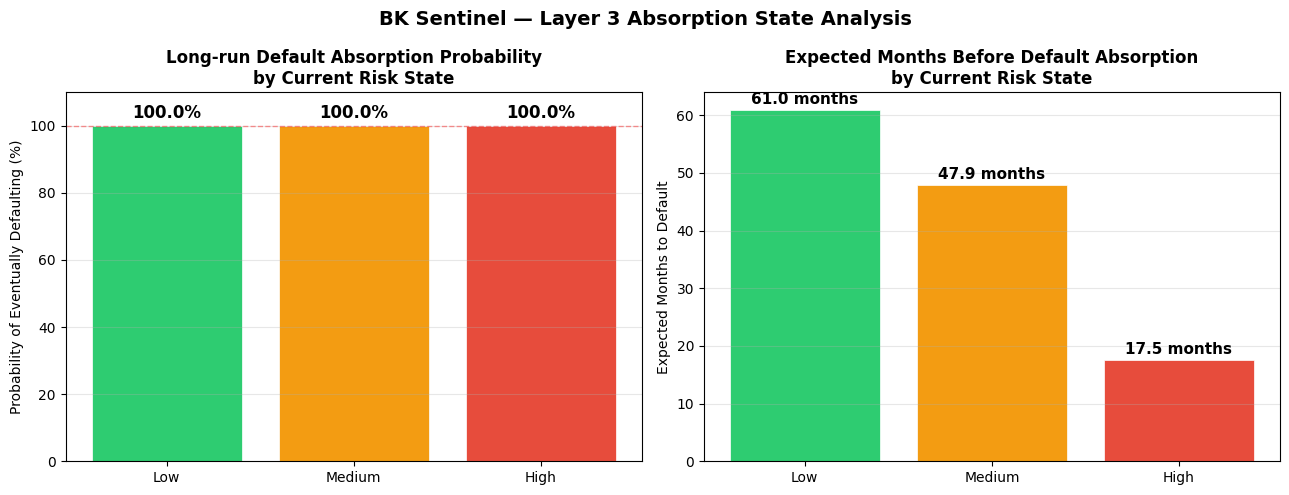

Absorption analysis chart saved.


In [22]:
# Plot 1: Absorption probabilities bar chart
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Absorption probability
probs = [B[i, 0] * 100 for i in range(len(transient_states))]
bar_colors = [COLORS[s] for s in transient_states]

bars = axes[0].bar(transient_states, probs, color=bar_colors, edgecolor='white', linewidth=0.5)
axes[0].set_title('Long-run Default Absorption Probability\nby Current Risk State', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Probability of Eventually Defaulting (%)')
axes[0].set_ylim(0, 110)
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].axhline(y=100, color='red', linestyle='--', alpha=0.4, linewidth=1)
for bar, prob in zip(bars, probs):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{prob:.1f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')

# Expected months to Default
months = [t[i] for i in range(len(transient_states))]
bars2 = axes[1].bar(transient_states, months, color=bar_colors, edgecolor='white', linewidth=0.5)
axes[1].set_title('Expected Months Before Default Absorption\nby Current Risk State', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Expected Months to Default')
axes[1].grid(True, alpha=0.3, axis='y')
for bar, m in zip(bars2, months):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{m:.1f} months', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.suptitle('BK Sentinel — Layer 3 Absorption State Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('04_absorption_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Absorption analysis chart saved.')

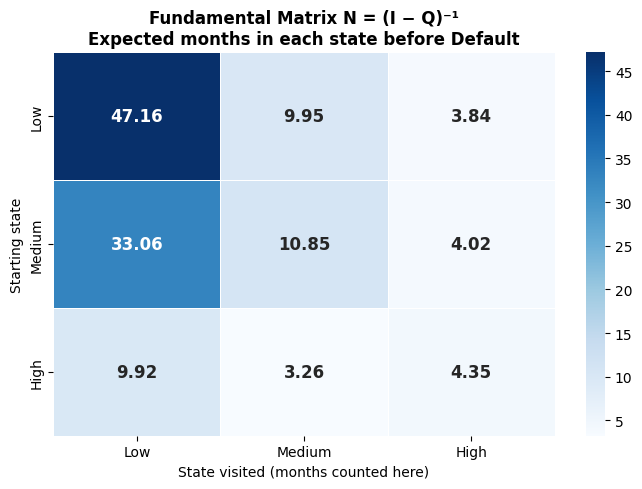

Fundamental matrix heatmap saved.


In [23]:
# Plot 2: Fundamental matrix heatmap
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    N_df, annot=True, fmt='.2f',
    cmap='Blues', linewidths=0.5, ax=ax,
    annot_kws={'size': 12, 'weight': 'bold'}
)
ax.set_title('Fundamental Matrix N = (I − Q)⁻¹\nExpected months in each state before Default',
             fontsize=12, fontweight='bold')
ax.set_xlabel('State visited (months counted here)', fontsize=10)
ax.set_ylabel('Starting state', fontsize=10)
plt.tight_layout()
plt.savefig('04_fundamental_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Fundamental matrix heatmap saved.')

In [24]:
# Plot 3: Full absorption summary table
summary = pd.DataFrame({
    'Current Risk State': transient_states,
    'P(eventual Default)': [f'{B[i,0]*100:.1f}%' for i in range(3)],
    'Expected months to Default': [f'{t[i]:.1f}' for i in range(3)],
    'Expected years to Default': [f'{t[i]/12:.1f}' for i in range(3)],
    'Intervention urgency': ['Low', 'Medium', 'HIGH — act now']
})

print('ABSORPTION ANALYSIS SUMMARY TABLE')
print('=' * 70)
print(summary.to_string(index=False))
print('=' * 70)

ABSORPTION ANALYSIS SUMMARY TABLE
Current Risk State P(eventual Default) Expected months to Default Expected years to Default Intervention urgency
               Low              100.0%                       61.0                       5.1                  Low
            Medium              100.0%                       47.9                       4.0               Medium
              High              100.0%                       17.5                       1.5       HIGH — act now


## 9. Key findings summary

In [25]:
print('=' * 60)
print('NOTEBOOK 04 COMPLETE — LAYER 3 KEY FINDINGS')
print('=' * 60)

print(f'\nAbsorbing state: Default (self-transition = {P[3,3]:.4f})')
print(f'Transient states: Low, Medium, High')

print(f'\nFundamental matrix N computed successfully via numpy.linalg.inv')

print(f'\nLong-run Default absorption probabilities (B = N x R):')
for i, state in enumerate(transient_states):
    print(f'  {state:<10}: {B[i,0]*100:.1f}% probability of eventually reaching Default')

print(f'\nExpected months before Default absorption:')
for i, state in enumerate(transient_states):
    print(f'  {state:<10}: {t[i]:.1f} months ({t[i]/12:.1f} years)')

print(f'\nBanking interpretation:')
print(f'  - A High-risk account has {B[2,0]*100:.1f}% long-run default probability')
print(f'    and is expected to reach Default in {t[2]:.1f} months without intervention.')
print(f'  - A Medium-risk account has {B[1,0]*100:.1f}% long-run default probability')
print(f'    and is expected to reach Default in {t[1]:.1f} months without intervention.')
print(f'  - A Low-risk account has {B[0,0]*100:.1f}% long-run default probability')
print(f'    and is expected to reach Default in {t[0]:.1f} months without intervention.')

print(f'\nAll three layers complete:')
print(f'  Layer 1 — ML classification:   DONE (Random Forest, macro F1 = 0.9361)')
print(f'  Layer 2 — Markov transition:    DONE (15 transition pairs, P^n forecasts)')
print(f'  Layer 3 — Absorption analysis:  DONE (N matrix, B matrix, t vector)')
print(f'\nNext: Build the Streamlit dashboard')

NOTEBOOK 04 COMPLETE — LAYER 3 KEY FINDINGS

Absorbing state: Default (self-transition = 0.9972)
Transient states: Low, Medium, High

Fundamental matrix N computed successfully via numpy.linalg.inv

Long-run Default absorption probabilities (B = N x R):
  Low       : 100.0% probability of eventually reaching Default
  Medium    : 100.0% probability of eventually reaching Default
  High      : 100.0% probability of eventually reaching Default

Expected months before Default absorption:
  Low       : 61.0 months (5.1 years)
  Medium    : 47.9 months (4.0 years)
  High      : 17.5 months (1.5 years)

Banking interpretation:
  - A High-risk account has 100.0% long-run default probability
    and is expected to reach Default in 17.5 months without intervention.
  - A Medium-risk account has 100.0% long-run default probability
    and is expected to reach Default in 47.9 months without intervention.
  - A Low-risk account has 100.0% long-run default probability
    and is expected to reach D

## 10. Save outputs for dashboard

In [26]:
# Save all Layer 3 outputs
N_df.to_csv('bk_fundamental_matrix.csv')
B_df.to_csv('bk_absorption_probabilities.csv')

# Save expected time to absorption
t_df = pd.DataFrame({
    'risk_state': transient_states,
    'absorption_probability': [round(B[i,0], 6) for i in range(3)],
    'expected_months_to_default': [round(t[i], 2) for i in range(3)],
    'expected_years_to_default': [round(t[i]/12, 2) for i in range(3)]
})
t_df.to_csv('bk_time_to_absorption.csv', index=False)

# Save Q and R matrices
Q_df.to_csv('bk_Q_matrix.csv')
R_df.to_csv('bk_R_matrix.csv')

print('Layer 3 outputs saved:')
print('  bk_fundamental_matrix.csv      — N = (I - Q)^-1')
print('  bk_absorption_probabilities.csv — B = N x R')
print('  bk_time_to_absorption.csv       — expected months to Default per state')
print('  bk_Q_matrix.csv                 — transient to transient matrix')
print('  bk_R_matrix.csv                 — transient to absorbing matrix')

Layer 3 outputs saved:
  bk_fundamental_matrix.csv      — N = (I - Q)^-1
  bk_absorption_probabilities.csv — B = N x R
  bk_time_to_absorption.csv       — expected months to Default per state
  bk_Q_matrix.csv                 — transient to transient matrix
  bk_R_matrix.csv                 — transient to absorbing matrix
